In [1]:
from pathlib import Path
from LHC_FillingPattern import LHCFillingPattern 
import matplotlib.pyplot as plt
import numpy as np
import dask.dataframe as dd
import pathlib
import pandas as pd
from pprint import pprint
import math
import pyarrow.dataset as ds
from scipy.stats import linregress
from lmfit import Model 
import warnings
from matplotlib.dates import DateFormatter
from typing import Optional

In [2]:
# user settings
beam = "B1"
ip   = "1"
PLANE_DEFAULT = 'H'   
RAWDATA = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
FILLINFO       = Path("/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info")
fbmodes        = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
fbmodes[(fbmodes.BMODE == "STABLE") & (fbmodes.duration > 5*3600*1.0e9)].head()
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709]) 

In [3]:
fbmodes[(fbmodes.BMODE == "STABLE")].head()

,BMODE,tsStart,tsEnd,QFLAG,duration,duration [m],duration [h],HX:AMODE,injection_scheme
FILLNO,,,,,,,,,
10489,STABLE,1745305756726488525,1745306445773738525,STABLE,689047250000,11.484121,0.191402,9.0,Single_12b_8_8_8_1bpi_12inj
10491,STABLE,1745308696263613525,1745326091176238525,STABLE,17394912625000,289.915210,4.831920,9.0,Single_12b_8_8_8_1bpi_12inj
10530,STABLE,1745692769664238525,1745701404414363525,STABLE,8634750125000,143.912502,2.398542,9.0,Single_12b_8_8_8_1bpi_12inj
10589,STABLE,1746445729803613525,1746449925971738525,STABLE,4196168125000,69.936135,1.165602,9.0,Single_4b_2_2_2_noLRs
10590,STABLE,1746456976242238525,1746489950314613525,STABLE,32974072375000,549.567873,9.159465,9.0,Single_12b_8_8_8_1bpi_12inj


In [4]:
# ------------------------------------------------------------------
# Build Families for ONE fill
# ------------------------------------------------------------------
def build_families_for_fill(
    fillno: int,
    beam: str,
    ip: str,
    RAWDATA: Path,
    long_gap_set=(32, 63),
    small_gap=8,
    F4_offset_after_long=6,    # 7th bunch (bid_first + 6)
    # F5_offset_after_long removed from use; Family_5 now from small-gap trains
    F6_offset_before_small=26, # 27th bunch (bid_first + 26)
    enforce_filled=True,
    intensity_threshold=None,
) -> dict:
    # --- Fetch filling pattern object ---
    fpat = LHCFillingPattern(fillno, RAWDATA)

    # beam-specific train table & "filled" mask
    if beam.upper() == "B1":
        trains = fpat.bunchtrainsDF_b1.copy()
        filled_slots = fpat.bunches_b1
    else:
        trains = fpat.bunchtrainsDF_b2.copy()
        filled_slots = fpat.bunches_b2

    trains = (
        trains.loc[trains["id"] != 0]
              .sort_values("bid_first")
              .reset_index(drop=True)
    )

    orbit_len = 3564

    # --- optional BUNCH_INTENSITY for filtering ---
    if intensity_threshold is not None:
        int_var = f"LHC.BCTFR.B6R4.{beam}:BUNCH_INTENSITY"
        ser_int = load_series(int_var, RAWDATA, fillno=fillno)  # helper below
        if ser_int.empty:
            arr_intensity = np.zeros(orbit_len, dtype=float)
        else:
            last_vals = np.asarray(ser_int.iloc[-1])
            if last_vals.shape[0] != orbit_len:
                tmp = np.zeros(orbit_len, dtype=float)
                n = min(orbit_len, last_vals.shape[0])
                tmp[:n] = last_vals[:n]
                last_vals = tmp
            arr_intensity = last_vals
    else:
        arr_intensity = None

    # ---- filter helpers ------------------------------------------------
    filled_mask = np.zeros(orbit_len, dtype=bool)
    filled_mask[filled_slots] = True

    def _filter(arr: np.ndarray) -> np.ndarray:
        if arr.size == 0:
            return arr
        arr = arr.astype(int)
        if enforce_filled:
            arr = arr[filled_mask[arr]]
        if arr_intensity is not None and intensity_threshold is not None:
            arr = arr[arr_intensity[arr] >= intensity_threshold]
        return arr

    # ------------------------------------------------------------------
    # Family_1: first bunch of trains whose *preceding* gap is long (32 or 63)
    # ------------------------------------------------------------------
    mask_long = trains["gap"].isin(long_gap_set)
    Family_1 = trains.loc[mask_long, "bid_first"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_2: last bunch of a train that is followed by a long (≥31) gap
    # ------------------------------------------------------------------
    next_start = trains["bid_first"].shift(-1).fillna(orbit_len).astype(int)
    trains["gap_after"] = next_start - trains["bid_last"] - 1
    mask_big_gap = trains["gap_after"] >= 31
    Family_2 = trains.loc[mask_big_gap, "bid_last"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_3: first slot of max LR encounter per train
    # ------------------------------------------------------------------
    lr = fpat.lrencounters[beam][f"ip{ip}"]  # length-3564 array
    peak_slots = []
    for _, row in trains.iterrows():
        bids = np.asarray(row["bids"], dtype=int)
        lr_train = lr[bids]
        max_val = lr_train.max()
        first_idx = np.where(lr_train == max_val)[0][0]
        peak_slots.append(bids[first_idx])
    Family_3 = np.asarray(peak_slots, dtype=int)

    # ------------------------------------------------------------------
    # Family_4: 7th bunch in long-gap trains (bid_first + 6)
    # ------------------------------------------------------------------
    Family_4 = (trains.loc[mask_long, "bid_first"] + F4_offset_after_long).to_numpy(int)

    # ------------------------------------------------------------------
    # Family_5 (MODIFIED): 15th bunch in trains whose *preceding* gap == small_gap
    #                      (e.g., gap == 8). Require nbunches >= 15.
    # ------------------------------------------------------------------
    mask_gap_small_15 = (trains["gap"] == small_gap) & (trains["nbunches"] >= 15)
    cand_F5 = (trains.loc[mask_gap_small_15, "bid_first"] + 14).to_numpy(int)
    # clip to each selected train's end (safety)
    last_F5 = trains.loc[mask_gap_small_15, "bid_last"].to_numpy(int)
    Family_5 = cand_F5[cand_F5 <= last_F5]

    # ------------------------------------------------------------------
    # Family_6: 27th bunch IN THE TRAIN *BEFORE* a gap==8 train
    # ------------------------------------------------------------------
    rows_gap8 = trains["gap"] == small_gap
    train_before_gap8 = trains.shift(1).loc[rows_gap8].dropna()
    mask_nbunch27 = train_before_gap8["nbunches"] >= (F6_offset_before_small + 1)
    Family_6 = (train_before_gap8.loc[mask_nbunch27, "bid_first"] + F6_offset_before_small).to_numpy(int)

    # ------------------------------------------------------------------
    # Family_7: first bunch AFTER an 8-slot gap (the gap8 train itself)
    # ------------------------------------------------------------------
    Family_7 = trains.loc[rows_gap8, "bid_first"].to_numpy(int)

    # ------------------------------------------------------------------
    # Family_8: last bunch BEFORE each gap8 (the last bunch of the previous train)
    # ------------------------------------------------------------------
    train_before_gap8_full = trains.shift(1).loc[rows_gap8].dropna()
    Family_8 = train_before_gap8_full["bid_last"].astype(int).to_numpy()

    # ------------------------------------------------------------------
    # apply filters
    # ------------------------------------------------------------------
    fam_dict = {
        "Family_1": _filter(Family_1),
        "Family_2": _filter(Family_2),
        "Family_3": _filter(Family_3),
        "Family_4": _filter(Family_4),
        "Family_5": _filter(Family_5),
        "Family_6": _filter(Family_6),
        "Family_7": _filter(Family_7),
        "Family_8": _filter(Family_8),
    }

    # report
    #print(f"\n=== Families for fill {fillno} ({beam}, {ip}) ===")
    ##for k, v in fam_dict.items():
        #print(f"{k}: n={len(v)}  slots={v}")

    return fam_dict


# ------------------------------------------------------------------
# Minimal load_series helper (same as in larger module)
# ------------------------------------------------------------------
def load_series(var: str, RAWDATA: Path, fillno: int) -> pd.Series:
    root = RAWDATA / f"HX:FILLN={fillno}"
    parts = []
    for pq in root.rglob("*.parquet"):
        try:
            df = pd.read_parquet(pq, columns=[var])
        except Exception:
            continue
        idx = pd.to_datetime(df.index, utc=True, errors="coerce")
        ser = pd.Series(df[var].to_numpy(), index=idx, name=var)
        parts.append(ser.dropna())
    if not parts:
        return pd.Series(dtype=float, name=var)
    return pd.concat(parts).sort_index()


In [5]:
fams_by_fill = {}
records = []   # for long DataFrame

for fillno in fills:
    fams = build_families_for_fill(
        fillno=fillno,
        beam=beam,
        ip=ip,
        RAWDATA=RAWDATA,
        # (optionally pass thresholds/offset overrides if needed)
    )
    fams_by_fill[fillno] = fams
# ------------------------------------------------------------------
# group back by fill -> dict, then assemble as columns
wide_rows = []
for fillno, fams in fams_by_fill.items():
    row = {"fill": fillno}
    for fam_name, slots in fams.items():
        row[fam_name] = np.array(slots, dtype=int)  # ragged arrays stored as objects
    wide_rows.append(row)

df_families_wide = pd.DataFrame(wide_rows)
print("df_families_wide shape:", df_families_wide.shape)
display(df_families_wide)

df_families_wide shape: (14, 9)


,fill,Family_1,Family_2,Family_3,Family_4,Family_5,Family_6,Family_7,Family_8
0,10665,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
1,10666,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
2,10671,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
3,10673,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
4,10675,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
5,10676,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
6,10685,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
7,10689,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
8,10690,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 16...","[71, 114, 157, 224, 267, 310, 353, 420, 463, 5...","[61, 214, 410, 606, 802, 955, 1108, 1304, 1500...","[112, 155, 265, 308, 351, 461, 504, 547, 657, ...","[81, 124, 234, 277, 320, 430, 473, 516, 626, 6...","[98, 141, 251, 294, 337, 447, 490, 533, 643, 6...","[90, 133, 243, 286, 329, 439, 482, 525, 635, 6..."
9,10701,"[55, 208, 404, 600, 796, 949, 1102, 1298, 1494...","[176, 372, 568, 764, 917, 1070, 1266, 1462, 1

In [6]:
def _ip_collision_sets_for_fill(fillno: int, beam: str, RAWDATA: Path):
    fpat = LHCFillingPattern(fillno, RAWDATA)

    if beam.upper() == "B1":
        ip15 = np.asarray(fpat.collbid_ip15["B1"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B1"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B1"], dtype=int)
    else:
        ip15 = np.asarray(fpat.collbid_ip15["B2"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B2"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B2"], dtype=int)

    return {
        "15": set(ip15),
        "2":  set(ip2),
        "8":  set(ip8),
    }

# Classify a numpy array of slots into exclusive IP groups

def _classify_slots_by_ip(slots: np.ndarray, set15, set2, set8):
    """
    Given 1D int array `slots` and three sets (IP15, IP2, IP8),
    return dict {ip_group_label: np.ndarray([...])}.
    """
    slots = np.asarray(slots, dtype=int)

    # for each slot, boolean membership
    in15 = np.array([s in set15 for s in slots], dtype=bool)
    in2  = np.array([s in set2  for s in slots], dtype=bool)
    in8  = np.array([s in set8  for s in slots], dtype=bool)

    # masks
    m15_only   =  in15 & ~in2 & ~in8
    m2_only    = ~in15 &  in2 & ~in8
    m8_only    = ~in15 & ~in2 &  in8

    m15_2      =  in15 &  in2 & ~in8
    m15_8      =  in15 & ~in2 &  in8
    m2_8       = ~in15 &  in2 &  in8

    m15_2_8    =  in15 &  in2 &  in8

    # any that did not match any of above (should be none or "non colliding")
    mnone      = ~(m15_only | m2_only | m8_only | m15_2 | m15_8 | m2_8 | m15_2_8)

    return {
        "15_only":   slots[m15_only],
        "2_only":    slots[m2_only],
        "8_only":    slots[m8_only],
        "15_2":      slots[m15_2],
        "15_8":      slots[m15_8],
        "2_8":       slots[m2_8],
        "15_2_8":    slots[m15_2_8],
        "none":      slots[mnone],
    }

# Main: explode fams_by_fill into IP-partitioned long & summary DFs
def build_family_ip_partitions(
    fams_by_fill: dict,
    RAWDATA: Path,
    beam: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Parameters
    ----------
    fams_by_fill : dict
        {fill: {"Family_1": array([...]), ...}}
    RAWDATA : Path
        root rawdata path
    beam : str
        'B1' or 'B2'

    Returns
    -------
    df_families_ip_long : DataFrame
        columns: fill, family, ip_group, slot
    df_families_ip_summary : DataFrame
        columns: fill, family, 15_only, 2_only, 8_only, 15_2, 15_8, 2_8, 15_2_8, none
        counts per group.
    """
    long_records = []
    summary_records = []

    for fillno, fams in fams_by_fill.items():
        # Get IP sets for this fill
        ip_sets = _ip_collision_sets_for_fill(fillno, beam, RAWDATA)
        set15, set2, set8 = ip_sets["15"], ip_sets["2"], ip_sets["8"]

        for fam_name, slots in fams.items():
            slots = np.asarray(slots, dtype=int)

            part_dict = _classify_slots_by_ip(slots, set15, set2, set8)

            # long rows
            for ip_group, arr in part_dict.items():
                for s in arr:
                    long_records.append({
                        "fill": fillno,
                        "family": fam_name,
                        "ip_group": ip_group,
                        "slot": int(s),
                    })

            # summary counts
            rec = {
                "fill": fillno,
                "family": fam_name,
            }
            for ip_group, arr in part_dict.items():
                rec[ip_group] = int(len(arr))
            summary_records.append(rec)

    # assemble long
    if long_records:
        df_families_ip_long = (
            pd.DataFrame.from_records(long_records)
              .sort_values(["fill", "family", "ip_group", "slot"])
              .reset_index(drop=True)
        )
    else:
        df_families_ip_long = pd.DataFrame(columns=["fill", "family", "ip_group", "slot"])

    # assemble summary
    if summary_records:
        df_families_ip_summary = (
            pd.DataFrame.from_records(summary_records)
              .sort_values(["fill", "family"])
              .reset_index(drop=True)
        )
    else:
        df_families_ip_summary = pd.DataFrame(columns=["fill", "family"])

    return df_families_ip_long, df_families_ip_summary

df_families_ip_long, df_families_ip_summary = build_family_ip_partitions(
    fams_by_fill=fams_by_fill,
    RAWDATA=RAWDATA,
    beam=beam,          # same beam as used when building families
)

print("df_families_ip_long shape:", df_families_ip_long.shape)
display(df_families_ip_long.head())

print("df_families_ip_summary shape:", df_families_ip_summary.shape)
display(df_families_ip_summary.head(9))

df_families_ip_long shape: (4494, 4)


,fill,family,ip_group,slot
0,10665,Family_1,15_2_8,1843
1,10665,Family_1,15_2_8,1996
2,10665,Family_1,15_2_8,2192
3,10665,Family_1,15_2_8,2388
4,10665,Family_1,15_8,55


df_families_ip_summary shape: (112, 10)


,fill,family,15_only,2_only,8_only,15_2,15_8,2_8,15_2_8,none
0,10665,Family_1,5,0,0,0,10,0,4,0
1,10665,Family_2,0,0,0,1,6,0,12,0
2,10665,Family_3,0,0,0,2,3,0,63,0
3,10665,Family_4,0,0,0,5,1,0,13,0
4,10665,Family_5,0,0,0,1,2,0,46,0
5,10665,Family_6,0,0,0,2,1,0,46,0
6,10665,Family_7,2,0,0,0,36,0,11,0
7,10665,Family_8,0,0,0,2,1,0,46,0
8,10666,Family_1,5,0,0,0,10,0,4,0


# ATLAS AND CMS AVERAGE LUMI ACROSS ALL FILLS

/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:185: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1703847588.py:106: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0_stb).round("S")
/tmp/kpervain/ipykernel_1648

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


/tmp/kpervain/ipykernel_1648663/1703847588.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/1703847588.py:214: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
/tmp/kpervain/ipykernel_1648663/1703847588.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start=start, end=stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/1703847588.py:214: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
/tmp/kpervain/ipykernel_1648663/1703847588.py:210: FutureWarning: 'T' is deprecated and will be removed in a future version, please 

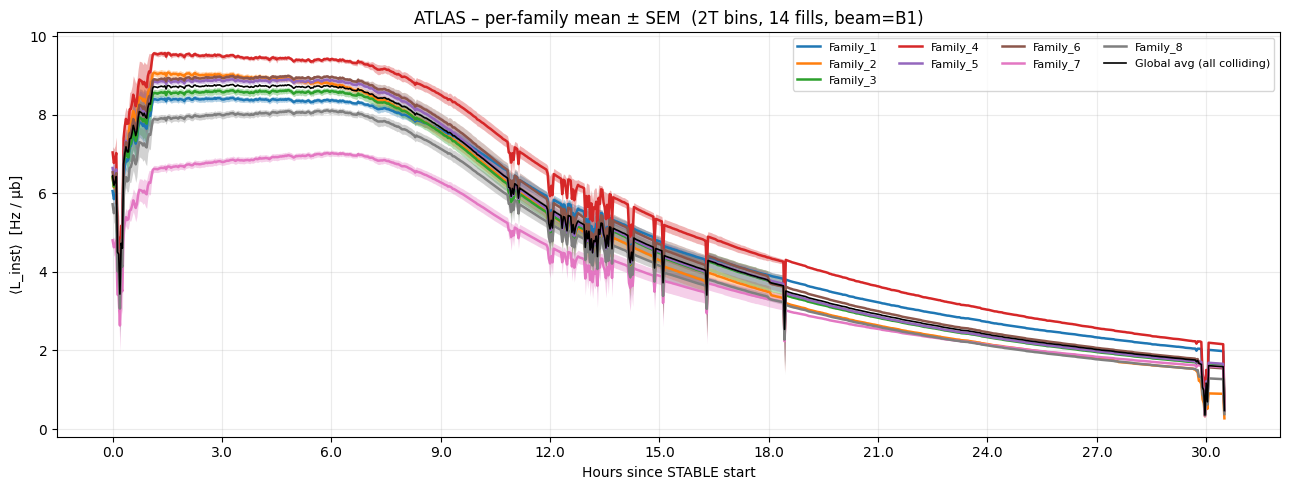

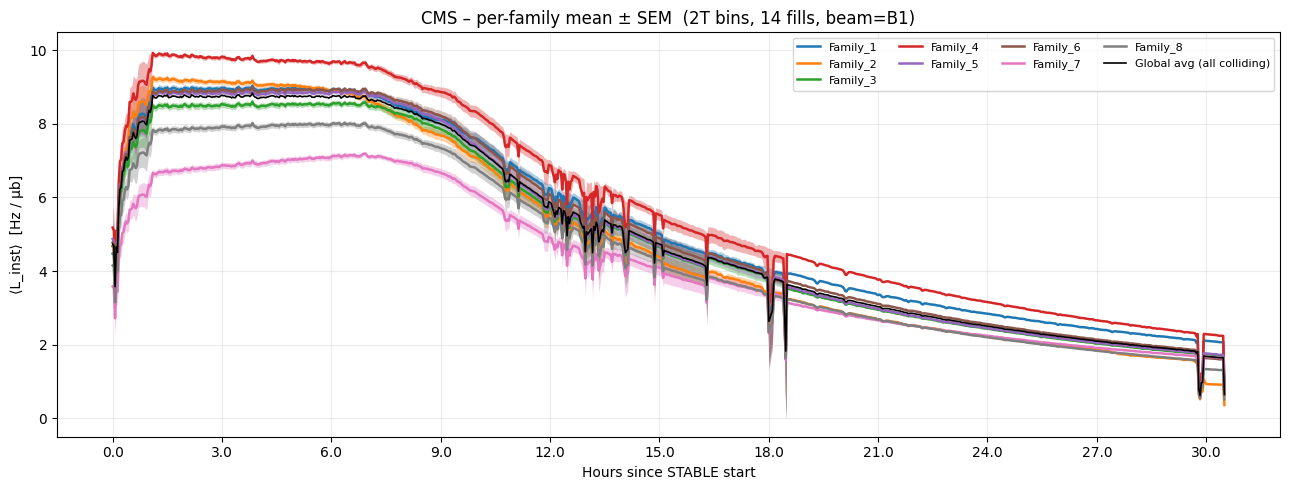

In [ ]:
# thids============================= configuration ===================================
from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


RAWDATA  = Path(RAWDATA)
FILLINFO = Path(FILLINFO)

# Exactly your 14 fills:
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

RESAMPLE      = "2T"   # common grid step (e.g. "1T", "2T", "30S")
FAMILY_ORDER  = [f"Family_{k}" for k in range(1, 9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
ATLAS_PV = "ATLAS:BUNCH_LUMI_INST"
CMS_PV   = "CMS:BUNCH_LUMI_INST"
_BMODE_PREF = ("STABLE", "ADJUST", "FLATTOP", "RAMP")

# ============================ filesystem helpers ================================
def _looks_like_fill_dir(p: Path, fno: int) -> bool:
    if not p.is_dir(): return False
    nm = p.name
    if f"HX:FILLN={fno}" in nm: return True
    return re.search(rf"(FILLN|fill|FILL)[^0-9]*{fno}(?!\d)", nm) is not None or nm == str(fno)

def _locate_fill_dir(root: Path, fno: int) -> Path | None:
    """Find directory that contains this fill. Checks root and one level below."""
    exact = root / f"HX:FILLN={fno}"
    if exact.is_dir():
        return exact
    for d in root.iterdir():
        if not d.is_dir(): 
            continue
        cand = d / f"HX:FILLN={fno}"
        if cand.is_dir():
            return cand
        if _looks_like_fill_dir(d, fno):
            return d
    return None

def _choose_bmode(fill_dir: Path) -> str | None:
    opts = [p for p in fill_dir.glob("HX:BMODE=*") if p.is_dir()]
    if not opts: return None
    names = {p.name.split("=", 1)[-1] for p in opts}
    for pref in _BMODE_PREF:
        if pref in names:
            return pref
    return sorted(names)[0]

# ===================== time window & per-fill accumulation ======================
def _stable_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = (fbmodes.loc[fno]
                    .query("BMODE=='STABLE'")
                    .sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _colliding_slots_for_fill(fno: int, beam: str, dataroot: Path, bmode: str | None) -> np.ndarray:
    """Union of colliding slots for this fill via LHCFillingPattern."""
    try:
        if bmode:
            LHCFillingPattern.bmode = bmode
        fpat = LHCFillingPattern(fno, dataroot)  # pass Path
    except Exception as e:
        print(f"[skip] fill {fno}: LHCFillingPattern failed ({e})")
        return np.array([], dtype=int)
    try:
        if beam.upper() == "B1":
            s15 = set(np.asarray(fpat.collbid_ip15["B1"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B1"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B1"], dtype=int))
        else:
            s15 = set(np.asarray(fpat.collbid_ip15["B2"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B2"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B2"], dtype=int))
        return np.array(sorted(s15 | s2 | s8), dtype=int)
    except Exception as e:
        print(f"[skip] fill {fno}: deriving colliding slots failed ({e})")
        return np.array([], dtype=int)

def _add_family_curves(ser_det: pd.Series,
                       M_det:   np.ndarray,
                       families: dict[str, np.ndarray],
                       t0_stb:  pd.Timestamp,
                       store   : dict[str, list[pd.Series]]) -> None:
    """
    Append per-family mean-over-slots time series to store[fam].
    IMPORTANT: zero-align each fill so collapse grid lines up across fills.
    """
    # Timedelta since STABLE start, rounded to whole seconds
    td_index = (ser_det.index - t0_stb).round("S")
    # Force all fills to start exactly at 0
    td_index = td_index - td_index.min()

    for fam, slots in families.items():
        if not len(slots):
            continue
        slots = np.asarray(slots, dtype=int)
        curve = np.nanmean(M_det[:, slots], axis=1)
        store.setdefault(fam, []).append(pd.Series(curve, index=td_index))

# ======================= per-fill collection (families + global) ================
def _collect_detector(det_pv: str, RAWDATA: Path, fills_exact: list[int]):
    RAWDATA = Path(RAWDATA)  # ensure Path
    fam_store: dict[str, list[pd.Series]] = {f: [] for f in FAMILY_ORDER}
    global_store: list[pd.Series] = []

    missing, used = [], []
    for fno in fills_exact:
        fdir = _locate_fill_dir(RAWDATA, int(fno))
        if fdir is None:
            print(f"[skip] fill {fno}: not found under RAWDATA")
            missing.append(fno)
            continue

        bmode = _choose_bmode(fdir)
        if not bmode:
            print(f"[skip] fill {fno}: no HX:BMODE=* under {fdir}")
            missing.append(fno)
            continue
        LHCFillingPattern.bmode = bmode

        # data_root is the parent that contains HX:FILLN=...
        data_root = fdir.parent if fdir.name.startswith("HX:FILLN=") else RAWDATA

        # STABLE window
        try:
            t0, t1 = _stable_window_utc(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: STABLE window not found ({e})")
            missing.append(fno)
            continue

        # families for this fill
        try:
            families = build_families_for_fill(fillno=fno, beam=beam, ip=ip, RAWDATA=data_root)
        except Exception as e:
            print(f"[skip] fill {fno}: build_families_for_fill failed ({e})")
            missing.append(fno)
            continue

        # detector per-bunch series for this fill
        try:
            s = load_series(det_pv, data_root, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {det_pv} ({e})")
            missing.append(fno)
            continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no {det_pv} data in STABLE window")
            missing.append(fno)
            continue

        try:
            M = np.stack(s.values)  # shape (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stack detector array failed ({e})")
            missing.append(fno)
            continue

        # per-family curves for this fill (zero-aligned)
        _add_family_curves(s, M, families, t0, fam_store)

        # global (all colliding) curve for this fill (also zero-aligned)
        slots_all = _colliding_slots_for_fill(fno, beam, data_root, bmode)
        if slots_all.size:
            curve_all = np.nanmean(M[:, slots_all], axis=1)
            td_index  = (s.index - t0).round("S")
            td_index  = td_index - td_index.min()
            global_store.append(pd.Series(curve_all, index=td_index))

        used.append(fno)

    print(f"[info] requested fills: {list(fills_exact)}")
    print(f"[info] used {len(used)} fills: {used}")
    if missing:
        print(f"[warn] missing/failed {len(missing)} fills: {missing}")

    return fam_store, global_store

# ======================= collapse across fills to mean ± SEM ====================
def _mean_sem_from_list(series_list: list[pd.Series],
                        freq: str = RESAMPLE) -> tuple[pd.Series, pd.Series]:
    """
    Collapse a list of Timedelta-indexed Series (already zero-aligned) to mean ± SEM
    on a common grid starting at 0.
    """
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    start = pd.Timedelta(0)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start=start, end=stop, freq=freq)

    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
        sr = sr.reindex(grid)                       # NaN where this fill has no data
        cols.append(sr.rename(None))

    df = pd.concat(cols, axis=1)                    # columns = fills
    mean = df.mean(axis=1, skipna=True)

    n   = df.count(axis=1)
    std = df.std(axis=1, ddof=1)                    # NaN when n<2
    sem = (std / np.sqrt(n.where(n > 0, 1))).where(n >= 2, 0.0)

    return mean, sem

def _collapse_series_list_to_mean(series_list: list[pd.Series]) -> pd.Series:
    m, _ = _mean_sem_from_list(series_list)
    return m

def _collapse_family_dict(family_dict: dict[str, list[pd.Series]]):
    """Return (mean_series_by_family, sem_by_family); one Series per family."""
    mean_by_fam, sem_by_fam = {}, {}
    for fam in FAMILY_ORDER:
        m, s = _mean_sem_from_list(family_dict.get(fam, []))
        mean_by_fam[fam] = m
        sem_by_fam[fam]  = s
    return mean_by_fam, sem_by_fam

# =============================== run the pipeline ===============================
atlas_fam_store, atlas_global_store = _collect_detector(ATLAS_PV, RAWDATA, fills.tolist())
cms_fam_store,   cms_global_store   = _collect_detector(CMS_PV, RAWDATA, fills.tolist())

curves_A, sems_A = _collapse_family_dict(atlas_fam_store)     # per-family mean ± SEM across fills
curves_C, sems_C = _collapse_family_dict(cms_fam_store)

global_A_mean = _collapse_series_list_to_mean(atlas_global_store)  # global mean across fills
global_C_mean = _collapse_series_list_to_mean(cms_global_store)

# ================================== plotting ===================================
def _plot_detector(det_name: str,
                   curves: dict[str, pd.Series],
                   sems:   dict[str, pd.Series],
                   global_mean: pd.Series,
                   ylab: str,
                   ylim: tuple[float, float] | None = None,
                   sem_alpha: float = 0.35):
    fig, ax = plt.subplots(figsize=(13, 5))
    plotted_any = False

    for k, fam in enumerate(FAMILY_ORDER):
        m = curves.get(fam, pd.Series(dtype=float))
        if m is None or m.empty:
            continue
        s = sems.get(fam, pd.Series(dtype=float))

        col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))
        xh  = (m.index.total_seconds() / 3600.0).astype(float)
        y   = m.to_numpy()

        # SEM band (mask NaNs)
        if s is not None and not s.empty:
            ylo = (m - s).to_numpy()
            yhi = (m + s).to_numpy()
            mask = np.isfinite(xh) & np.isfinite(ylo) & np.isfinite(yhi)
            if mask.any():
                ax.fill_between(xh[mask], ylo[mask], yhi[mask],
                                color=col, alpha=sem_alpha, lw=0, zorder=1)

        ax.plot(xh, y, lw=1.8, color=col, label=fam, zorder=2)
        plotted_any = True

    if global_mean is not None and not global_mean.empty:
        gx = (global_mean.index.total_seconds() / 3600.0).astype(float)
        gy = global_mean.to_numpy()
        ax.plot(gx, gy, 'k-', lw=1.2, label="Global avg (all colliding)", zorder=3)
        plotted_any = True

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.set_xlabel("Hours since STABLE start")
    ax.set_ylabel(ylab)
    ax.set_title(f"{det_name} – per-family mean ± SEM  ({RESAMPLE} bins, {len(fills)} fills, beam={beam})")
    ax.grid(alpha=.25)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if plotted_any:
        ax.legend(ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()

# ---- final figures (set ylim if you want)
_ = _plot_detector("ATLAS", curves_A, sems_A, global_A_mean, "⟨L_inst⟩  [Hz / μb]",
                   ylim=None, sem_alpha=0.35)
_ = _plot_detector("CMS",   curves_C, sems_C, global_C_mean, "⟨L_inst⟩  [Hz / μb]",
                   ylim=None, sem_alpha=0.35)


# Ips

/tmp/kpervain/ipykernel_1648663/1431971834.py:107: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1431971834.py:183: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1431971834.py:107: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1431971834.py:183: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index  = (s.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/1431971834.py:107: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td_index = (ser_det.index - t0).round("S")
/tmp/kpervain/ipykernel_1648663/14319718

[info] requested fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]
[info] used 14 fills: [10665, 10666, 10671, 10673, 10675, 10676, 10685, 10689, 10690, 10701, 10717, 10721, 10732, 10709]


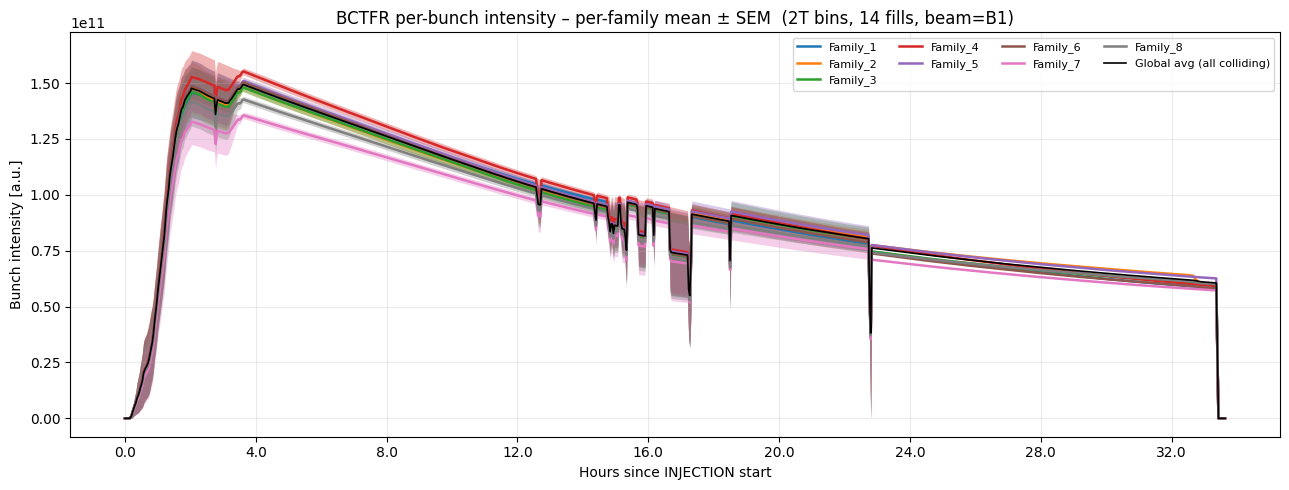

In [ ]:
# ============================= configuration ===================================
from pathlib import Path
import re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Ensure these exist in your session:
# RAWDATA  = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/rawdata')
# FILLINFO = Path('/eos/project/l/lhc-lumimod/LuminosityFollowUp/2025/fills-info')
# fbmodes  = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
# beam, ip
# functions: build_families_for_fill, LHCFillingPattern, load_series

RAWDATA  = Path(RAWDATA)
FILLINFO = Path(FILLINFO)

# Exactly your 14 fills:
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

RESAMPLE      = "2T"   # common grid step (e.g. "1T", "2T", "30S")
FAMILY_ORDER  = [f"Family_{k}" for k in range(1, 9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}
_BMODE_PREF = ("STABLE", "ADJUST", "FLATTOP", "RAMP")

def _intensity_pv(beam: str) -> str:
    b = "B1" if beam.upper() == "B1" else "B2"
    return f"LHC.BCTFR.A6R4.{b}:BUNCH_INTENSITY"

INTENSITY_PV = _intensity_pv(beam)

# ============================ filesystem helpers ================================
def _looks_like_fill_dir(p: Path, fno: int) -> bool:
    if not p.is_dir(): return False
    nm = p.name
    if f"HX:FILLN={fno}" in nm: return True
    return re.search(rf"(FILLN|fill|FILL)[^0-9]*{fno}(?!\d)", nm) is not None or nm == str(fno)

def _locate_fill_dir(root: Path, fno: int) -> Path | None:
    """Find directory that contains this fill. Checks root and one level below."""
    exact = root / f"HX:FILLN={fno}"
    if exact.is_dir():
        return exact
    for d in root.iterdir():
        if not d.is_dir():
            continue
        cand = d / f"HX:FILLN={fno}"
        if cand.is_dir():
            return cand
        if _looks_like_fill_dir(d, fno):
            return d
    return None

def _choose_bmode(fill_dir: Path) -> str | None:
    opts = [p for p in fill_dir.glob("HX:BMODE=*") if p.is_dir()]
    if not opts: return None
    names = {p.name.split("=", 1)[-1] for p in opts}
    for pref in _BMODE_PREF:
        if pref in names:
            return pref
    return sorted(names)[0]

# ===================== time window & per-fill accumulation ======================
def _inj_to_end_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    """Earliest BMODE start (≈ first injection) → last BMODE end (≈ dump/end)."""
    rows = fbmodes.loc[fno].sort_values("tsStart")
    t0 = pd.to_datetime(rows["tsStart"].iloc[0], utc=True)
    t1 = pd.to_datetime(rows["tsEnd"  ].iloc[-1], utc=True)
    return t0, t1

def _colliding_slots_for_fill(fno: int, beam: str, dataroot: Path, bmode: str | None) -> np.ndarray:
    """Union of colliding slots for this fill via LHCFillingPattern."""
    try:
        if bmode:
            LHCFillingPattern.bmode = bmode
        fpat = LHCFillingPattern(fno, dataroot)  # pass Path
    except Exception as e:
        print(f"[skip] fill {fno}: LHCFillingPattern failed ({e})")
        return np.array([], dtype=int)
    try:
        if beam.upper() == "B1":
            s15 = set(np.asarray(fpat.collbid_ip15["B1"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B1"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B1"], dtype=int))
        else:
            s15 = set(np.asarray(fpat.collbid_ip15["B2"], dtype=int))
            s2  = set(np.asarray(fpat.collbid_ip2 ["B2"], dtype=int))
            s8  = set(np.asarray(fpat.collbid_ip8 ["B2"], dtype=int))
        return np.array(sorted(s15 | s2 | s8), dtype=int)
    except Exception as e:
        print(f"[skip] fill {fno}: deriving colliding slots failed ({e})")
        return np.array([], dtype=int)

def _add_family_curves(ser_det: pd.Series,
                       M_det:   np.ndarray,
                       families: dict[str, np.ndarray],
                       t0:      pd.Timestamp,
                       store   : dict[str, list[pd.Series]]) -> None:
    """
    Append per-family mean-over-slots time series to store[fam].
    IMPORTANT: zero-align each fill at injection so collapse grid lines up across fills.
    """
    td_index = (ser_det.index - t0).round("S")
    td_index = td_index - td_index.min()   # force t=0 start

    for fam, slots in families.items():
        if not len(slots):
            continue
        slots = np.asarray(slots, dtype=int)
        curve = np.nanmean(M_det[:, slots], axis=1)
        store.setdefault(fam, []).append(pd.Series(curve, index=td_index))

# ======================= per-fill collection (families + global) ================
def _collect_intensity(RAWDATA: Path, fills_exact: list[int]):
    RAWDATA = Path(RAWDATA)  # ensure Path
    fam_store: dict[str, list[pd.Series]] = {f: [] for f in FAMILY_ORDER}
    global_store: list[pd.Series] = []

    missing, used = [], []
    for fno in fills_exact:
        fdir = _locate_fill_dir(RAWDATA, int(fno))
        if fdir is None:
            print(f"[skip] fill {fno}: not found under RAWDATA")
            missing.append(fno)
            continue

        bmode = _choose_bmode(fdir)
        if not bmode:
            print(f"[skip] fill {fno}: no HX:BMODE=* under {fdir}")
            missing.append(fno)
            continue
        LHCFillingPattern.bmode = bmode
        data_root = fdir.parent if fdir.name.startswith("HX:FILLN=") else RAWDATA

        # injection → end window
        try:
            t0, t1 = _inj_to_end_window_utc(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: injection→end window error ({e})")
            missing.append(fno)
            continue

        # families for this fill
        try:
            families = build_families_for_fill(fillno=fno, beam=beam, ip=ip, RAWDATA=data_root)
        except Exception as e:
            print(f"[skip] fill {fno}: build_families_for_fill failed ({e})")
            missing.append(fno)
            continue

        # per-bunch INTENSITY for this fill
        try:
            s = load_series(INTENSITY_PV, data_root, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {INTENSITY_PV} ({e})")
            missing.append(fno)
            continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no intensity data in injection→end window")
            missing.append(fno)
            continue

        try:
            M = np.stack(s.values)  # shape (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stack detector array failed ({e})")
            missing.append(fno)
            continue

        # per-family curves for this fill (zero-aligned at injection)
        _add_family_curves(s, M, families, t0, fam_store)

        # global (all colliding) curve for this fill (also zero-aligned)
        slots_all = _colliding_slots_for_fill(fno, beam, data_root, bmode)
        if slots_all.size:
            curve_all = np.nanmean(M[:, slots_all], axis=1)
            td_index  = (s.index - t0).round("S")
            td_index  = td_index - td_index.min()
            global_store.append(pd.Series(curve_all, index=td_index))

        used.append(fno)

    print(f"[info] requested fills: {list(fills_exact)}")
    print(f"[info] used {len(used)} fills: {used}")
    if missing:
        print(f"[warn] missing/failed {len(missing)} fills: {missing}")

    return fam_store, global_store

# ======================= collapse across fills to mean ± SEM ====================
def _mean_sem_from_list(series_list: list[pd.Series],
                        freq: str = RESAMPLE) -> tuple[pd.Series, pd.Series]:
    """
    Collapse a list of Timedelta-indexed Series (already zero-aligned) to mean ± SEM
    on a common grid starting at 0.
    """
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    start = pd.Timedelta(0)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start=start, end=stop, freq=freq)

    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean()   # put on RESAMPLE step
        sr = sr.reindex(grid)                       # NaN where this fill has no data
        cols.append(sr.rename(None))

    df = pd.concat(cols, axis=1)                    # columns = fills
    mean = df.mean(axis=1, skipna=True)

    n   = df.count(axis=1)
    std = df.std(axis=1, ddof=1)                    # NaN when n<2
    sem = (std / np.sqrt(n.where(n > 0, 1))).where(n >= 2, 0.0)

    return mean, sem

def _collapse_series_list_to_mean(series_list: list[pd.Series]) -> pd.Series:
    m, _ = _mean_sem_from_list(series_list)
    return m

def _collapse_family_dict(family_dict: dict[str, list[pd.Series]]):
    """Return (mean_series_by_family, sem_by_family); one Series per family."""
    mean_by_fam, sem_by_fam = {}, {}
    for fam in FAMILY_ORDER:
        m, s = _mean_sem_from_list(family_dict.get(fam, []))
        mean_by_fam[fam] = m
        sem_by_fam[fam]  = s
    return mean_by_fam, sem_by_fam

# =============================== run the pipeline ===============================
int_fam_store, int_global_store = _collect_intensity(RAWDATA, fills.tolist())

curves_I, sems_I = _collapse_family_dict(int_fam_store)         # per-family mean ± SEM across fills
global_I_mean    = _collapse_series_list_to_mean(int_global_store)


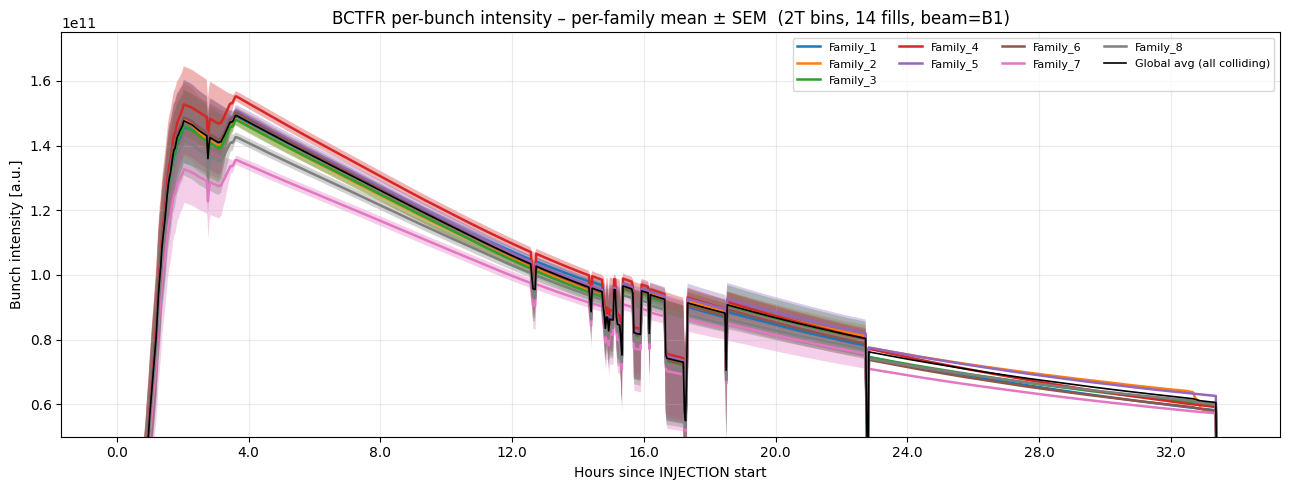

In [12]:

# ================================== plotting ===================================
def _plot_intensity(curves: dict[str, pd.Series],
                    sems:   dict[str, pd.Series],
                    global_mean: pd.Series,
                    ylim: tuple[float, float] | None = None,
                    sem_alpha: float = 0.35):
    fig, ax = plt.subplots(figsize=(13, 5))
    plotted_any = False

    for k, fam in enumerate(FAMILY_ORDER):
        m = curves.get(fam, pd.Series(dtype=float))
        if m is None or m.empty:
            continue
        s = sems.get(fam, pd.Series(dtype=float))

        col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))
        xh  = (m.index.total_seconds() / 3600.0).astype(float)
        y   = m.to_numpy()

        # SEM band (mask NaNs)
        if s is not None and not s.empty:
            ylo = (m - s).to_numpy()
            yhi = (m + s).to_numpy()
            mask = np.isfinite(xh) & np.isfinite(ylo) & np.isfinite(yhi)
            if mask.any():
                ax.fill_between(xh[mask], ylo[mask], yhi[mask],
                                color=col, alpha=sem_alpha, lw=0, zorder=1)

        ax.plot(xh, y, lw=1.8, color=col, label=fam, zorder=2)
        plotted_any = True

    if global_mean is not None and not global_mean.empty:
        gx = (global_mean.index.total_seconds() / 3600.0).astype(float)
        gy = global_mean.to_numpy()
        ax.plot(gx, gy, 'k-', lw=1.2, label="Global avg (all colliding)", zorder=3)
        plotted_any = True

    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.set_xlabel("Hours since INJECTION start")
    ax.set_ylabel("Bunch intensity [a.u.]")
    ax.set_title(f"BCTFR per-bunch intensity – per-family mean ± SEM  "
                 f"({RESAMPLE} bins, {len(fills)} fills, beam={beam})")
    ax.grid(alpha=.25)
    ax.set_ylim(0.5e11,1.75e11)
    if ylim is not None:
        ax.set_ylim(*ylim)
    if plotted_any:
        ax.legend(ncol=4, fontsize=8)
    fig.tight_layout()
    plt.show()

# ---- final figure (set ylim if you want)
_ = _plot_intensity(curves_I, sems_I, global_I_mean,
                    ylim=None, sem_alpha=0.35)


/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td -

[info] requested fills: [np.int64(10665), np.int64(10666), np.int64(10671), np.int64(10673), np.int64(10675), np.int64(10676), np.int64(10685), np.int64(10689), np.int64(10690), np.int64(10701), np.int64(10717), np.int64(10721), np.int64(10732), np.int64(10709)]
[info] used 14 fills: [np.int64(10665), np.int64(10666), np.int64(10671), np.int64(10673), np.int64(10675), np.int64(10676), np.int64(10685), np.int64(10689), np.int64(10690), np.int64(10701), np.int64(10717), np.int64(10721), np.int64(10732), np.int64(10709)]


/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start, stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/3524924615.py:91: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start, stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/3524924615.py:91: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range

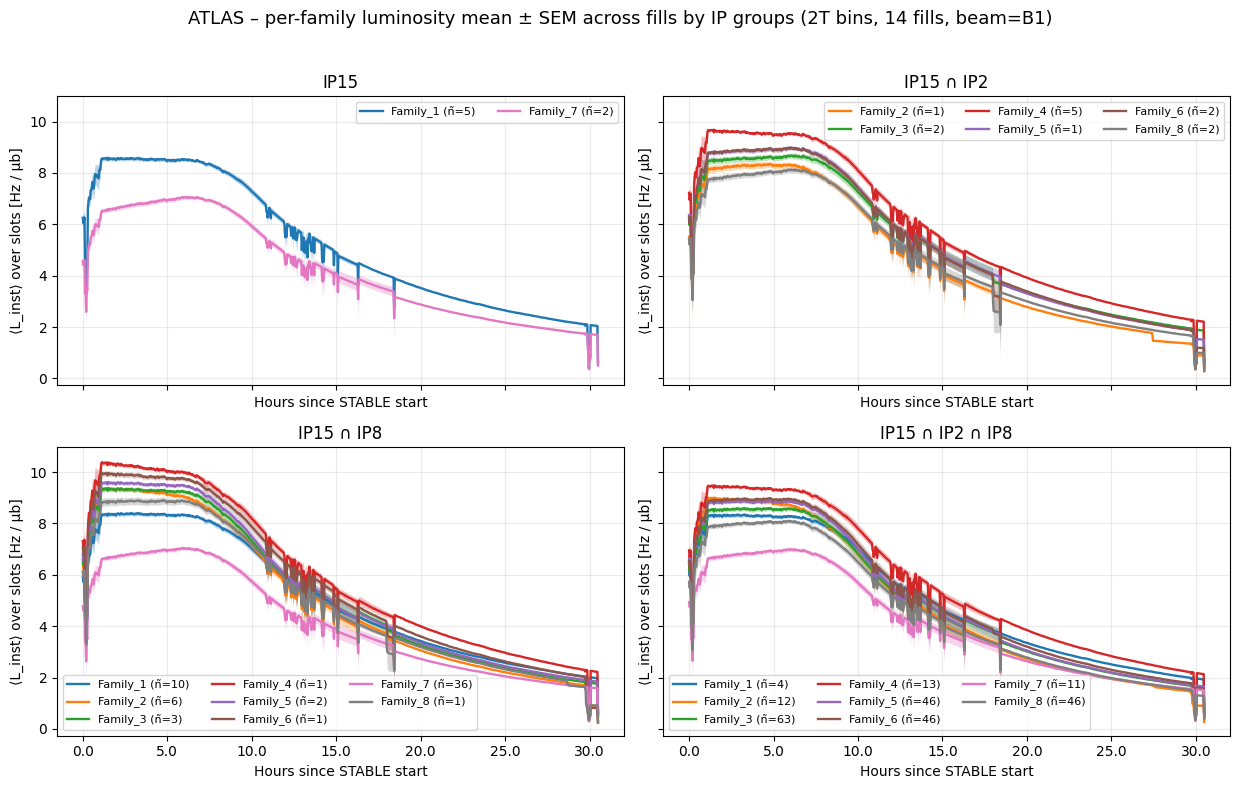

/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td - td.min()
/tmp/kpervain/ipykernel_1648663/3524924615.py:169: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  td = (s.index - t0).round("S"); td = td -

[info] requested fills: [np.int64(10665), np.int64(10666), np.int64(10671), np.int64(10673), np.int64(10675), np.int64(10676), np.int64(10685), np.int64(10689), np.int64(10690), np.int64(10701), np.int64(10717), np.int64(10721), np.int64(10732), np.int64(10709)]
[info] used 14 fills: [np.int64(10665), np.int64(10666), np.int64(10671), np.int64(10673), np.int64(10675), np.int64(10676), np.int64(10685), np.int64(10689), np.int64(10690), np.int64(10701), np.int64(10717), np.int64(10721), np.int64(10732), np.int64(10709)]


/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start, stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/3524924615.py:91: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range(start, stop, freq=freq)
/tmp/kpervain/ipykernel_1648663/3524924615.py:91: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  sr = s.sort_index().resample(freq).mean().reindex(grid)
/tmp/kpervain/ipykernel_1648663/3524924615.py:88: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  grid  = pd.timedelta_range

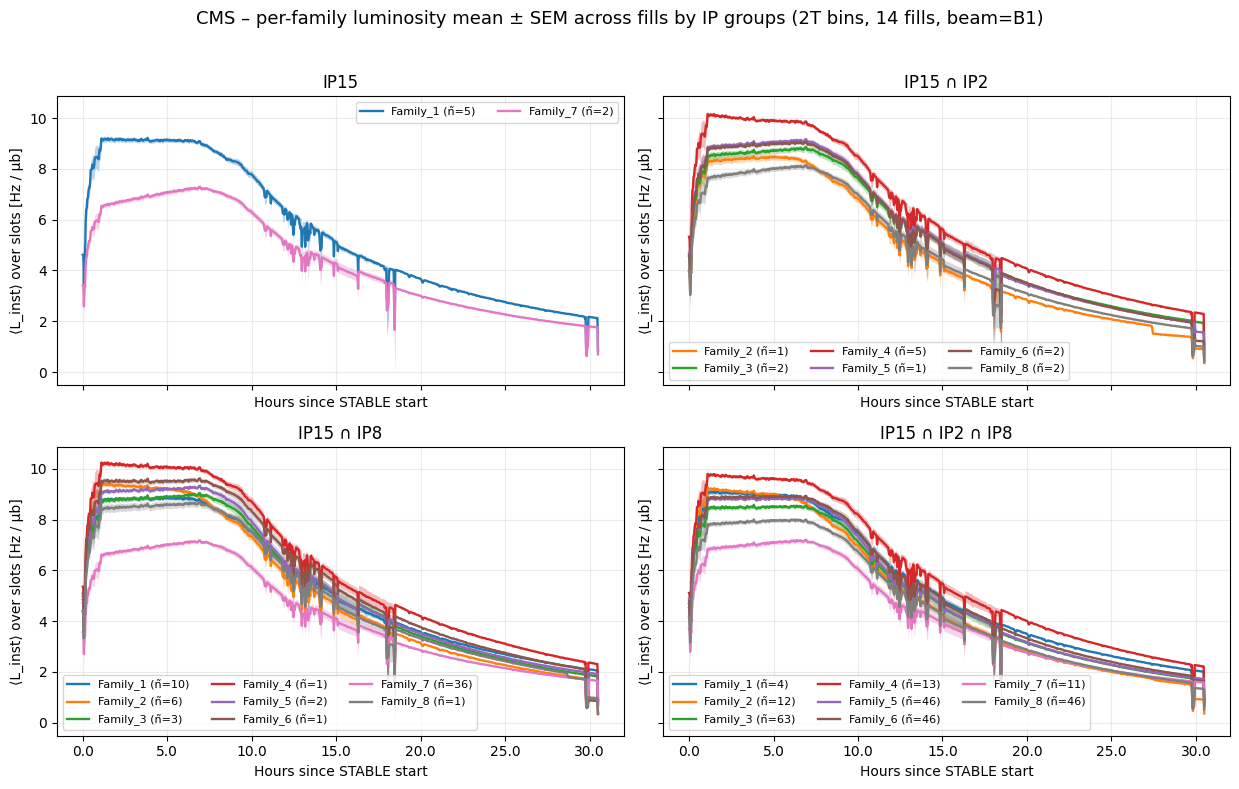

In [10]:
# ============ Luminosity averaged across fills, classified by IP groups =========
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Expected in your session:
# RAWDATA  = Path('/eos/.../2025/rawdata')
# FILLINFO = Path('/eos/.../2025/fills-info')
# fbmodes  = pd.read_parquet(FILLINFO / "fills_and_bmodes_2025.parquet")
# beam     = "B1" or "B2"
# ip       = what your build_families_for_fill expects (see _build_families_safe)
# funcs    = LHCFillingPattern, build_families_for_fill, load_series

RAWDATA = Path(RAWDATA)

# your fills
fills = np.array([10665,10666,10671,10673,10675,10676,10685,10689,10690,10701,10717,10721,10732,10709])

# detector PVs
ATLAS_PV = "ATLAS:BUNCH_LUMI_INST"
CMS_PV   = "CMS:BUNCH_LUMI_INST"

# config
RESAMPLE = "2T"  # resample step for the common time grid
USE_INJECTION_TO_END = False  # set True if you ever want injection→end

FAMILY_ORDER  = [f"Family_{k}" for k in range(1,9)]
FAMILY_COLORS = {
    "Family_1":"#1f77b4","Family_2":"#ff7f0e","Family_3":"#2ca02c","Family_4":"#d62728",
    "Family_5":"#9467bd","Family_6":"#8c564b","Family_7":"#e377c2","Family_8":"#7f7f7f",
}

# ---------- IP helpers ----------
def _ip_collision_sets_for_fill(fillno: int, beam: str, RAWDATA: Path):
    fpat = LHCFillingPattern(fillno, RAWDATA)
    if beam.upper() == "B1":
        ip15 = np.asarray(fpat.collbid_ip15["B1"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B1"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B1"], dtype=int)
    else:
        ip15 = np.asarray(fpat.collbid_ip15["B2"], dtype=int)
        ip2  = np.asarray(fpat.collbid_ip2 ["B2"], dtype=int)
        ip8  = np.asarray(fpat.collbid_ip8 ["B2"], dtype=int)
    return {"15": set(ip15), "2": set(ip2), "8": set(ip8)}

def _classify_slots_by_ip(slots: np.ndarray, set15, set2, set8):
    slots = np.asarray(slots, dtype=int)
    in15 = np.array([s in set15 for s in slots], dtype=bool)
    in2  = np.array([s in set2  for s in slots], dtype=bool)
    in8  = np.array([s in set8  for s in slots], dtype=bool)
    m15_only   =  in15 & ~in2 & ~in8
    m15_2      =  in15 &  in2 & ~in8
    m15_8      =  in15 & ~in2 &  in8
    m15_2_8    =  in15 &  in2 &  in8
    return {
        "15_only": slots[m15_only],
        "15_2":    slots[m15_2],
        "15_8":    slots[m15_8],
        "15_2_8":  slots[m15_2_8],
    }

# ---------- windows ----------
def _stable_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = (fbmodes.loc[fno].query("BMODE=='STABLE'").sort_values("tsStart"))
    if rows.empty:
        rows = fbmodes.loc[fno].sort_values("tsEnd").iloc[[-1]]
    return (pd.to_datetime(rows["tsStart"].iloc[0], utc=True),
            pd.to_datetime(rows["tsEnd"  ].iloc[0], utc=True))

def _inj_to_end_window_utc(fno: int) -> tuple[pd.Timestamp, pd.Timestamp]:
    rows = fbmodes.loc[fno].sort_values("tsStart")
    t0 = pd.to_datetime(rows["tsStart"].iloc[0], utc=True)
    t1 = pd.to_datetime(rows["tsEnd"  ].iloc[-1], utc=True)
    return t0, t1

def _window_for_fill(fno: int):
    return _inj_to_end_window_utc(fno) if USE_INJECTION_TO_END else _stable_window_utc(fno)

# ---------- collapse helpers ----------
def _mean_sem_from_list(series_list: list[pd.Series], freq: str = RESAMPLE):
    """Series must have a TimedeltaIndex starting at 0. Return mean and SEM across fills."""
    if not series_list:
        return pd.Series(dtype=float), pd.Series(dtype=float)
    start = pd.Timedelta(0)
    stop  = max(s.index.max() for s in series_list)
    grid  = pd.timedelta_range(start, stop, freq=freq)
    cols = []
    for s in series_list:
        sr = s.sort_index().resample(freq).mean().reindex(grid)
        cols.append(sr.rename(None))
    df   = pd.concat(cols, axis=1)
    mean = df.mean(axis=1, skipna=True)
    n    = df.count(axis=1)
    std  = df.std(axis=1, ddof=1)
    sem  = (std / np.sqrt(n.where(n>0, 1))).where(n>=2, 0.0)
    return mean, sem

# ---------- family builder (avoid the 'ipany' crash) ----------
def _normalize_ip(ip_val):
    s = str(ip_val).strip().upper()
    if s in {"15","IP15"}: return "15"
    if s in {"2","IP2"}:   return "2"
    if s in {"8","IP8"}:   return "8"
    # if user passes 'ANY' or others, default to a valid IP so the builder doesn't explode
    return "15"

def _build_families_safe(fillno: int, beam: str, RAWDATA: Path, ip_hint):
    # try as-is
    try:
        return build_families_for_fill(fillno=fillno, beam=beam, ip=ip_hint, RAWDATA=RAWDATA)
    except Exception:
        pass
    # try normalized string ("15"/"2"/"8")
    ip_norm = _normalize_ip(ip_hint)
    try:
        return build_families_for_fill(fillno=fillno, beam=beam, ip=ip_norm, RAWDATA=RAWDATA)
    except Exception:
        # try integer
        try:
            return build_families_for_fill(fillno=fillno, beam=beam, ip=int(ip_norm), RAWDATA=RAWDATA)
        except Exception as e:
            raise RuntimeError(f"build_families_for_fill failed for fill {fillno} with ip={ip_hint} ({e})")

# ---------- collect per-fill luminosity, group by IP, then average across fills --
_GROUPS_TO_PLOT = ["15_only", "15_2", "15_8", "15_2_8"]

def _collect_lumi_by_ip_across_fills(det_pv: str, fills, beam: str, RAWDATA: Path, ip_hint):
    """
    Returns:
      mean_by_group: {ip_group: {family: Series(mean across fills)}}
      sem_by_group : {ip_group: {family: Series(SEM across fills)}}
      nslots_stats : {ip_group: {family: median slots per fill}}
    """
    store  = {g: {fam: [] for fam in FAMILY_ORDER} for g in _GROUPS_TO_PLOT}
    nslots = {g: {fam: [] for fam in FAMILY_ORDER} for g in _GROUPS_TO_PLOT}

    used, skipped = [], []
    for fno in fills:
        # time window
        try:
            t0, t1 = _window_for_fill(fno)
        except Exception as e:
            print(f"[skip] fill {fno}: window error ({e})"); skipped.append(fno); continue

        # families (slot lists)
        try:
            fams = _build_families_safe(fno, beam, RAWDATA, ip_hint)
        except Exception as e:
            print(f"[skip] fill {fno}: families failed ({e})"); skipped.append(fno); continue

        # per-bunch luminosity for this detector
        try:
            s = load_series(det_pv, RAWDATA, fillno=fno)
        except Exception as e:
            print(f"[skip] fill {fno}: load_series failed for {det_pv} ({e})"); skipped.append(fno); continue

        s = s[(s.index >= t0) & (s.index <= t1)].dropna()
        if s.empty:
            print(f"[skip] fill {fno}: no {det_pv} data in window"); skipped.append(fno); continue

        try:
            M = np.stack(s.values)  # (n_times, 3564)
        except Exception as e:
            print(f"[skip] fill {fno}: stacking failed ({e})"); skipped.append(fno); continue

        # zero-align at window start
        td = (s.index - t0).round("S"); td = td - td.min()

        # IP sets and classify
        try:
            ips = _ip_collision_sets_for_fill(fno, beam, RAWDATA)
        except Exception as e:
            print(f"[skip] fill {fno}: IP sets failed ({e})"); skipped.append(fno); continue
        set15, set2, set8 = ips["15"], ips["2"], ips["8"]

        for fam, slots in fams.items():
            parts = _classify_slots_by_ip(np.asarray(slots, dtype=int), set15, set2, set8)
            for gkey in _GROUPS_TO_PLOT:
                sel = np.asarray(parts[gkey], dtype=int)
                if sel.size == 0:
                    continue
                curve = np.nanmean(M[:, sel], axis=1)              # mean over selected slots
                store[gkey][fam].append(pd.Series(curve, index=td))
                nslots[gkey][fam].append(int(sel.size))

        used.append(fno)

    print(f"[info] requested fills: {list(fills)}")
    print(f"[info] used {len(used)} fills: {used}")
    if skipped:
        print(f"[warn] skipped {len(skipped)} fills: {skipped}")

    # collapse across fills → mean ± SEM
    mean_by_group = {g:{} for g in _GROUPS_TO_PLOT}
    sem_by_group  = {g:{} for g in _GROUPS_TO_PLOT}
    nslots_stats  = {g:{} for g in _GROUPS_TO_PLOT}
    for gkey in _GROUPS_TO_PLOT:
        for fam in FAMILY_ORDER:
            m, s = _mean_sem_from_list(store[gkey][fam])
            if not m.empty:
                mean_by_group[gkey][fam] = m
                sem_by_group[gkey][fam]  = s
                ns = nslots[gkey][fam]
                nslots_stats[gkey][fam] = int(np.median(ns)) if ns else 0
    return mean_by_group, sem_by_group, nslots_stats

# ---------- plotting ----------
def plot_avg_lumi_by_ip_groups(det_name: str,
                               det_pv: str,
                               fills,
                               beam: str,
                               RAWDATA: Path,
                               ip_hint,                         # what your families builder expects
                               ylim: tuple[float,float] | None = None,
                               sem_alpha: float = 0.25):
    mean_by_group, sem_by_group, nstats = _collect_lumi_by_ip_across_fills(
        det_pv=det_pv, fills=fills, beam=beam, RAWDATA=RAWDATA, ip_hint=ip_hint
    )

    panels = [
        ("15_only", "IP15"),
        ("15_2",    "IP15 ∩ IP2"),
        ("15_8",    "IP15 ∩ IP8"),
        ("15_2_8",  "IP15 ∩ IP2 ∩ IP8"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for ax, (gkey, title) in zip(axes, panels):
        fam_means = mean_by_group.get(gkey, {})
        fam_sems  = sem_by_group.get(gkey, {})
        for k, fam in enumerate(FAMILY_ORDER):
            m = fam_means.get(fam)
            if m is None or m.empty:
                continue
            s = fam_sems.get(fam, pd.Series(dtype=float))
            col = FAMILY_COLORS.get(fam, plt.cm.tab10(k % 10))

            xh = m.index.total_seconds() / 3600.0
            ax.plot(xh, m.values, lw=1.7, color=col,
                    label=f"{fam} (ñ={nstats.get(gkey,{}).get(fam,0)})")
            if not s.empty:
                ylo, yhi = (m - s).values, (m + s).values
                ax.fill_between(xh, ylo, yhi, color=col, alpha=sem_alpha, lw=0)
        ax.set_title(title)
        ax.grid(alpha=.25)

    for ax in axes:
        ax.set_xlabel("Hours since " + ("injection start" if USE_INJECTION_TO_END else "STABLE start"))
        ax.set_ylabel("⟨L_inst⟩ over slots [Hz / μb]")
        if ylim: ax.set_ylim(*ylim)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
        if ax.lines:
            ax.legend(fontsize=8, ncol=3, frameon=True)

    fig.suptitle(
        f"{det_name} – per-family luminosity mean ± SEM across fills by IP groups "
        f"({RESAMPLE} bins, {len(list(fills))} fills, beam={beam})",
        y=0.98, fontsize=13
    )
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# ------------------- example calls -------------------
# STABLE window (default):
plot_avg_lumi_by_ip_groups("ATLAS", ATLAS_PV, fills, beam=beam, RAWDATA=RAWDATA, ip_hint=ip,
                                                    ylim=None, sem_alpha=0.3)
plot_avg_lumi_by_ip_groups("CMS",   CMS_PV,   fills, beam=beam, RAWDATA=RAWDATA, ip_hint=ip,
                            ylim=None, sem_alpha=0.3)

# If you ever want injection→end instead of STABLE:
# USE_INJECTION_TO_END = True
# plot_avg_lumi_by_ip_groups("ATLAS", ATLAS_PV, fills, beam=beam, RAWDATA=RAWDATA, ip_hint=ip)
